# Named Entity Recognition on the Archelec Corpus
## Sponsorship and Spatial Analysis of French Legislative Manifestos (1973–1993)

Author: Zakaria Bouliaire  
Course: Machine Learning for NLP — ENSAE 2026  
Supervisor: Christopher Kermorvant  

---

The Archelec corpus brings together the electoral manifestos of candidates in French 
legislative elections between 1973 and 1993. The documents were digitised and transcribed 
by OCR at Sciences Po, which means the texts carry the usual noise of automatic recognition — 
layout errors, inconsistent capitalisation, garbled characters. This is not unlike the 
AdminSet corpus from the NER lab, and the same precautions apply.

The project pursues two questions. First, which national political figures did candidates 
choose to invoke, and does that choice reflect alignment or distancing? Second, do 
candidates frame their discourse locally, nationally, or toward international stakes? 
Taken together, these two angles let us probe the rhetorical strategies of local 
candidates across twenty years of French political history.

## 1. Data

The corpus is organised by election year. Each year is stored as a zip archive containing 
one text file per page of each manifesto. The filename encodes all the metadata we need:

`EL067_L_1973_03_059_10_1_PF_04.txt`

- `EL067` — department code (here, Bas-Rhin)
- `L` — legislative election
- `1973_03` — March 1973
- `059` — constituency number
- `10` — candidate number within the constituency
- `1` — first round
- `PF` — profession de foi, as opposed to `BV` (bulletin de vote)
- `04` — page number

A single candidate can have many pages. Before any analysis, we group and concatenate 
all pages belonging to the same candidate. We keep only the profession de foi files 
and discard the bulletins de vote, which are too short to carry meaningful discourse.

The corpus covers five legislative elections: 1973, 1978, 1981, 1988 and 1993.

In [1]:
import os
import zipfile
import re
import json
import urllib.request
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy

%matplotlib inline

DATA_DIR = Path("data/arkindex_archelec/text_files")
YEARS = ["1973", "1978", "1981", "1988", "1993"]

## 2. Loading and parsing the corpus

Each zip archive is extracted and its files grouped by candidate. The filename structure 
gives us a unique identifier for each candidate — department, year, constituency, and 
candidate number. We concatenate all pages belonging to the same candidate into a single 
document, which becomes the unit of analysis throughout the notebook.

In [2]:
def parse_filename(filename):
    pattern = r"(EL\d+)_([A-Z]+)_(\d{4})_\d+_(\d+)_(\d+)_\d+_(PF|BV)_\d+\.txt"
    match = re.match(pattern, filename)
    if not match:
        return None
    dept, election_type, year, constituency, candidate_num, doc_type = match.groups()
    return {
        "dept": dept,
        "election_type": election_type,
        "year": int(year),
        "constituency": constituency,
        "candidate_num": candidate_num,
        "doc_type": doc_type,
        "candidate_id": f"{dept}_{year}_{constituency}_{candidate_num}"
    }

def extract_candidate_id(doc_id):
    parts = str(doc_id).split("_")
    if len(parts) >= 6:
        return f"{parts[0]}_{parts[2]}_{parts[4]}_{parts[5]}"
    return None

def load_corpus(data_dir, years):
    candidates = defaultdict(lambda: {"text": "", "metadata": None})
    for year in years:
        zip_path = data_dir / year / "legislatives.zip"
        if not zip_path.exists():
            print(f"Missing: {zip_path}")
            continue
        with zipfile.ZipFile(zip_path, "r") as zf:
            for name in zf.namelist():
                filename = Path(name).name
                meta = parse_filename(filename)
                if meta is None or meta["doc_type"] != "PF":
                    continue
                with zf.open(name) as f:
                    text = f.read().decode("utf-8", errors="replace")
                cid = meta["candidate_id"]
                candidates[cid]["text"] += " " + text
                candidates[cid]["metadata"] = meta
    return candidates

candidates = load_corpus(DATA_DIR, YEARS)
print(f"Total candidates loaded: {len(candidates)}")

Total candidates loaded: 2551


## 3. Exploratory data analysis

Before running any NER, it is worth getting a sense of what the corpus looks like. 
How many candidates per election year? How long are the manifestos on average? This 
serves both to spot potential data issues and to contextualise the results later.

Shape: (2551, 7)

Candidates per year:
year
1973    473
1978    478
1981    487
1988    562
1993    551
Name: candidate_id, dtype: int64

Text length (words):
count     2551.0
mean      5875.6
std       2678.4
min        643.0
25%       3772.0
50%       5446.0
75%       7529.0
max      17078.0
Name: n_words, dtype: float64


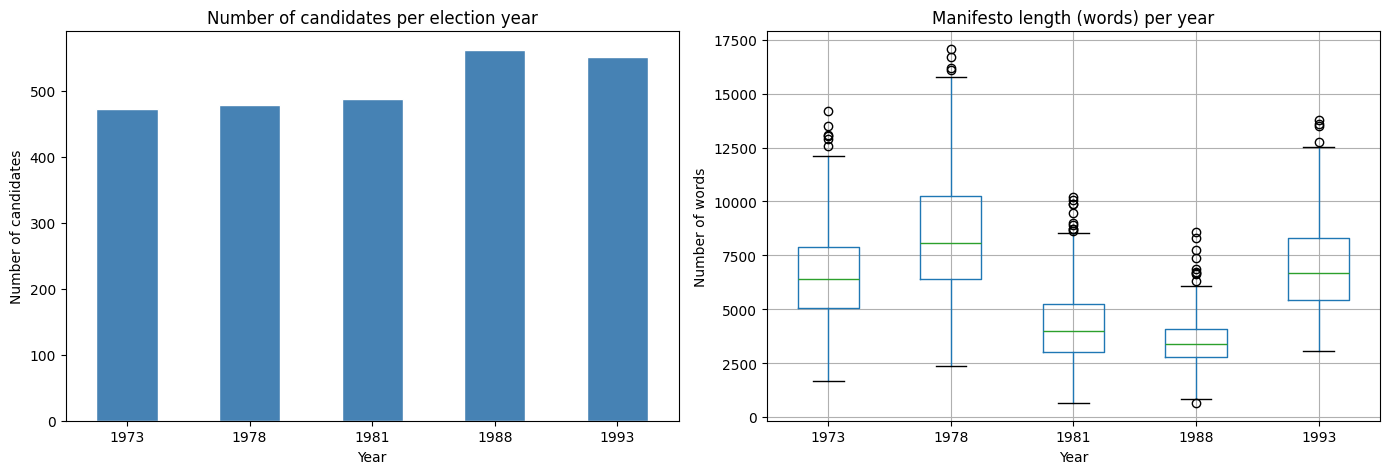

In [3]:
rows = []
for cid, data in candidates.items():
    meta = data["metadata"]
    text = data["text"].strip()
    rows.append({
        "candidate_id": cid,
        "year": meta["year"],
        "dept": meta["dept"],
        "constituency": meta["constituency"],
        "text": text,
        "n_chars": len(text),
        "n_words": len(text.split())
    })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")

print("\nCandidates per year:")
print(df.groupby("year")["candidate_id"].count())

print("\nText length (words):")
print(df["n_words"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("year")["candidate_id"].count().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Number of candidates per election year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of candidates")
axes[0].tick_params(axis="x", rotation=0)

df.boxplot(column="n_words", by="year", ax=axes[1])
axes[1].set_title("Manifesto length (words) per year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of words")
plt.suptitle("")

plt.tight_layout()
plt.show()

## 4. Text preprocessing

Two issues stand out from a first look at the raw texts. The OCR watermark 
"Sciences Po / fonds CEVIPOF" appears in many documents and would pollute entity 
extraction. And the heavy use of all-caps in electoral manifestos confuses spaCy's 
NER — words like "VOUS" or "VOTANT" get tagged as named entities. 

We remove the watermark and normalise whitespace. We deliberately avoid lowercasing 
everything, since spaCy relies on capitalisation to detect proper nouns.

In [4]:
def clean_text(text):
    text = re.sub(r"Sciences Po\s*/\s*fonds CEVIPOF[^\n]*", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["text"].apply(clean_text)

sample = df[df["text"].str.contains("Sciences Po")].iloc[0]
print("Before:", sample["text"][:200])
print("\nAfter:", sample["text_clean"][:200])

Before: 10me Circonscription
Elections Législatives - 4 Mars 1973
POURQUOI UNE OPPOSITION GAULLISTE ?
La "majorité" a trompé les Français : élue, certes par la grande peur de 1968, mais aussi au nom du gaulli

After: 10me Circonscription Elections Législatives - 4 Mars 1973 POURQUOI UNE OPPOSITION GAULLISTE ? La "majorité" a trompé les Français : élue, certes par la grande peur de 1968, mais aussi au nom du gaulli


## 5. Named Entity Recognition

We use `fr_core_news_lg`, the largest French model available in spaCy, pretrained on 
news and Wikipedia data. As in the NER lab, applying a pretrained model directly is a 
reasonable starting point — it gives us a baseline without requiring annotated data.

We extract two entity types: `PER` for person names and `LOC` for locations. The other 
types (`ORG`, `MISC`) generate too much noise on this OCR corpus to be useful. Processing 
2551 documents takes a few minutes, so we use `nlp.pipe()` for efficiency.

In [5]:
nlp = spacy.load("fr_core_news_lg")

def extract_entities(texts, batch_size=32):
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        persons = [ent.text.strip() for ent in doc.ents if ent.label_ == "PER"]
        locations = [ent.text.strip() for ent in doc.ents if ent.label_ == "LOC"]
        results.append({"persons": persons, "locations": locations})
    return results

print("Running NER on all candidates... (this may take a few minutes)")
ner_results = extract_entities(df["text_clean"].tolist())

df["persons"] = [r["persons"] for r in ner_results]
df["locations"] = [r["locations"] for r in ner_results]
df["n_persons"] = df["persons"].apply(len)
df["n_locations"] = df["locations"].apply(len)

print(f"Done. Average persons per manifesto: {df['n_persons'].mean():.1f}")
print(f"Done. Average locations per manifesto: {df['n_locations'].mean():.1f}")

Running NER on all candidates... (this may take a few minutes)
Done. Average persons per manifesto: 84.3
Done. Average locations per manifesto: 93.0


## 6. Metadata and party classification

Before analysing citations and geographic scope, we load the Archelec metadata CSV, 
which contains structured information about each candidate — name, party affiliation, 
department, constituency. We use the party field to group candidates into political 
families for the analyses that follow.

The raw party names in the metadata are highly heterogeneous — over 100 distinct 
values. We map them to a simplified classification through a combination of keyword 
matching and case-by-case judgement for smaller parties.

In [6]:
meta_df = pd.read_csv("data/metadata/archelect_search.csv", low_memory=False)
meta_df["candidate_id"] = meta_df["id"].apply(extract_candidate_id)
meta_df = meta_df.drop_duplicates(subset=["candidate_id"]).dropna(subset=["candidate_id"])

# Merge with corpus
df_party = df.merge(
    meta_df[["candidate_id", "titulaire-soutien"]],
    on="candidate_id", how="left"
)

PARTY_MAP = {
    "non mentionné": "Non mentionné", "indépendant": "Non mentionné",
    "aucun parti politique": "Non mentionné", "sans étiquette": "Non mentionné",
    "libre": "Non mentionné", "apolitique": "Non mentionné",
    "sans appartenance politique": "Non mentionné",
    "aucune appartenance politique;Association pour la défense des institutions dans l'intérêt supérieur de la France pour l'épanouissement de la famille": "Non mentionné",
    "Tahoeraa huiraatira": "Non mentionné", "Vida Nova": "Non mentionné",
    "Combat ouvrier": "Extrême gauche",
    "Comités communistes pour l'autogestion": "Extrême gauche",
    "Organisation communiste des travailleurs": "Extrême gauche",
    "Organisation communiste des travailleurs;Comités communistes autogestionnaires": "Extrême gauche",
    "communiste marxiste-léniniste": "Extrême gauche",
    "communistes fidèles au marxisme-léninisme et à la pensée de Mao Tsé-toung": "Extrême gauche",
    "communistes fidèles au marxisme-léninisme et à la pensée de Mao Tsé-toung;Parti communiste révolutionnaire": "Extrême gauche",
    "marxistes-léninistes": "Extrême gauche",
    "communiste": "PCF", "communistes": "PCF",
    "Radical de gauche": "Divers gauche",
    "Choisir la cause des femmes": "Divers gauche",
    "Union démocratique bretonne": "Divers gauche",
    "Front progressiste": "Divers gauche",
    "Front progressiste;Front des jeunes progressistes": "Divers gauche",
    "Ecologie occitane": "Divers gauche",
    "centriste": "Divers centre",
    "indépendant;social;libéral": "Divers centre",
    "hors des partis": "Divers centre",
    "hors des partis;Mouvement européen": "Divers centre",
    "Centre Démocratie et Progrès": "Divers centre",
    "Centre Démocratie et Progrès;Mouvement pour le socialisme par la participation": "Divers centre",
    "Centre des démocrates sociaux": "Divers centre",
    "Mouvement des démocrates": "Divers centre",
    "Réformateur": "Divers centre", "Réformateurs": "Divers centre",
    "Démocratie chrétienne": "Divers centre",
    "Chrétiens pour un monde nouveau": "Divers centre",
    "Civisme et progrès": "Divers centre",
    "Progrès et Liberté": "Divers centre",
    "Nouveau contrat social": "Divers centre",
    "Parti fédéraliste européen de France": "Divers centre",
    "Comité d'étude et de liaison des intérêts bretons": "Divers centre",
    "républicain": "Divers droite", "libéral": "Divers droite",
    "droite libérale": "Divers droite",
    "Union des Français de bon sens": "Divers droite",
    "Action républicaine indépendante et libérale": "Divers droite",
    "Alliance républicaine indépendante et libérale": "Divers droite",
    "Centre des républicains libres": "Divers droite",
    "Fédération libérale des Hauts-de-Seine;Rassemblement des indépendants pour la majorité nouvelle;indépendant;centriste": "Divers droite",
    "giscardien de progrès": "Divers droite",
    "Union des gaullistes de progrès": "RPR/Gaulliste",
    "Union des gaullistes de progrès;Union démocratique du travail": "RPR/Gaulliste",
    "gaulliste majoritaire": "RPR/Gaulliste",
    "Parti des forces nouvelles": "Extrême droite",
    "Parti des forces nouvelles;Groupe Union et défense": "Extrême droite",
    "Action royaliste": "Extrême droite",
}

def simplify_party(party):
    if not isinstance(party, str):
        return "Non mentionné"
    if party in PARTY_MAP:
        return PARTY_MAP[party]
    party_lower = party.lower()
    if "communiste français" in party_lower or "pcf" in party_lower:
        return "PCF"
    elif "lutte ouvrière" in party_lower or "ligue communiste" in party_lower \
         or "parti socialiste unifié" in party_lower:
        return "Extrême gauche"
    elif "parti socialiste" in party_lower or "fédération de la gauche" in party_lower \
         or "radicaux de gauche" in party_lower or "mouvement des radicaux" in party_lower \
         or "radical-socialiste" in party_lower or "socialiste" in party_lower:
        return "PS/Gauche"
    elif "rassemblement pour la république" in party_lower \
         or "union pour la nouvelle république" in party_lower \
         or "union des républicains de progrès" in party_lower \
         or "union des démocrates pour la" in party_lower \
         or "comité d'action pour la ve" in party_lower \
         or "fédération des républicains" in party_lower:
        return "RPR/Gaulliste"
    elif "républicains indépendants" in party_lower \
         or "républicain indépendant" in party_lower \
         or "union pour la démocratie française" in party_lower \
         or "centre démocrate" in party_lower \
         or "mouvement républicain populaire" in party_lower \
         or "mouvement réformateur" in party_lower \
         or "centre national des indépendants" in party_lower \
         or "parti républicain" in party_lower \
         or "indépendants et paysans" in party_lower \
         or "rassemblement démocratique" in party_lower:
        return "UDF/Centre-droit"
    elif "front national" in party_lower:
        return "FN"
    elif "écolo" in party_lower or "vert" in party_lower or "environnement" in party_lower:
        return "Écologiste"
    else:
        return "Non mentionné"

df_party["party"] = df_party["titulaire-soutien"].apply(simplify_party)
print("Party distribution:")
print(df_party["party"].value_counts())

Party distribution:
party
Non mentionné       1514
PCF                  321
Extrême gauche       250
PS/Gauche            155
RPR/Gaulliste        154
UDF/Centre-droit      81
Divers centre         27
Divers gauche         15
FN                    10
Divers droite         10
Écologiste             8
Extrême droite         6
Name: count, dtype: int64


The classification of smaller parties required case-by-case judgement. Parties with 
explicit ideological labels were straightforward — "communiste marxiste-léniniste" goes 
to the far left, "Action royaliste" to the far right. More ambiguous cases like 
"Civisme et progrès" or "Nouveau contrat social" were assigned to the centre based on 
their reformist rhetoric. Regional parties like "Union démocratique bretonne" were placed 
on the left given the historical orientation of Breton regionalism in this period. 
The 1,514 candidates with no party mention are excluded from party-based analyses.

## 7. Analysis — Part 1: Political personalities

The NER model detects on average 84 person entities per manifesto, which is suspiciously 
high. Inspection shows that many are OCR artefacts — all-caps words incorrectly tagged 
as names. We apply two successive filters: first keeping only entities with at least one 
lowercase letter, then removing titles, function names and other non-name tokens. We 
also normalise case to merge variants like "MITTERRAND" and "Mitterrand", and map known 
name variants to a single canonical form.

In [7]:
def filter_persons(persons):
    filtered = []
    for p in persons:
        if any(c.islower() for c in p) and len(p) >= 3:
            filtered.append(p)
    return filtered

STOPNAMES = {
    "Monsieur", "Madame", "Mademoiselle", "Président", "Maire", "Général",
    "Président De La République", "Premier Ministre", "Conseiller Municipal",
    "Prénom Adresse", "Mars", "Réanimer", "Ministre", "Député", "Sénateur",
    "Secrétaire", "Directeur", "Professeur", "Docteur", "France", "République",
    "Europe", "Paris", "Nation", "État", "Gouvernement", "Cher Monsieur",
    "Chère Mademoiselle", "Conseiller Général", "Maire De", "Premier Ministre"
}

def normalize_case(name):
    parts = name.split()
    normalized = []
    for part in parts:
        if "-" in part:
            normalized.append("-".join(w.capitalize() for w in part.split("-")))
        elif "'" in part:
            sub = part.split("'")
            normalized.append("'".join(w.capitalize() for w in sub))
        else:
            normalized.append(part.capitalize())
    return " ".join(normalized)

def filter_stopnames(persons):
    normalized = [normalize_case(p) for p in persons]
    return [p for p in normalized if p not in STOPNAMES and len(p.split()) >= 2]

CANONICAL = {
    "François Mitterrand": ["François Mitterand", "F. Mitterrand", "Mitterrand"],
    "Charles De Gaulle": ["Général De Gaulle", "De Gaulle", "Charles De Gaulle"],
    "Jacques Chirac": ["Chirac"],
    "Valéry Giscard D'Estaing": ["Giscard", "Giscard D'Estaing"],
    "Georges Pompidou": ["Pompidou", "Président Pompidou"],
    "Michel Rocard": ["Rocard"],
    "Jean-Marie Le Pen": ["Le Pen"],
    "Raymond Barre": ["Barre"],
    "Arlette Laguiller": ["Arlette Laguiller I.p.t."],
    "Georges Marchais": ["Marchais", "M. Marchais"],
    "André Lajoinie": ["Lajoinie", "André LAJOINIE"],
    "Pierre Mauroy": ["Mauroy"],
}

EXTRA_STOP = {
    "Cher Monsieur", "Chère Mademoiselle", "Cher Ami", "Chère Amie",
    "Conseiller Général", "Cher Électeur", "Chère Électrice", "Cher Compatriote",
    "- Relance", "- Relancer", "- Mitterrand", "M. Mitterrand",
    "Voter P.s.u.", "Président François Mitterrand", "Socialiste Madame"
}

name_to_canonical = {}
for canonical, variants in CANONICAL.items():
    for variant in variants:
        name_to_canonical[variant] = canonical
    name_to_canonical[canonical] = canonical

df["persons_clean"] = df["persons"].apply(filter_persons)
df["persons_final"] = df["persons_clean"].apply(filter_stopnames)
df["persons_norm"] = df["persons_final"].apply(
    lambda ps: [name_to_canonical.get(p, p) for p in ps
                if p not in EXTRA_STOP and len(p.split()) >= 2]
)

all_persons_norm = [p for persons in df["persons_norm"] for p in persons]
person_counts_norm = Counter(all_persons_norm)

print("Top 20 most cited political figures:")
for name, count in person_counts_norm.most_common(20):
    print(f"  {name}: {count}")

Top 20 most cited political figures:
  François Mitterrand: 6149
  Arlette Laguiller: 1480
  Charles De Gaulle: 1403
  Michel Rocard: 1278
  Valéry Giscard D'Estaing: 1065
  Jean-Marie Le Pen: 837
  Jacques Chirac: 750
  Georges Pompidou: 708
  Brice Lalonde: 585
  Pierre Mauroy: 380
  Raymond Barre: 325
  Georges Marchais: 315
  Guy Mollet: 309
  Edgar Faure: 250
  Maurice Faure: 220
  André Lajoinie: 214
  Robert Fabre: 201
  Jean-Marie Votez: 141
  Michel Jobert: 136
  Jean Lecanuet: 134


### 7.1 Who gets cited, and when?

The overall counts tell us who dominated the political discourse across the whole period, 
but the more interesting question is how citation patterns evolved over time. De Gaulle 
died in 1970 — do candidates still invoke him in 1988 and 1993? When does Mitterrand 
peak? When does Le Pen start appearing?

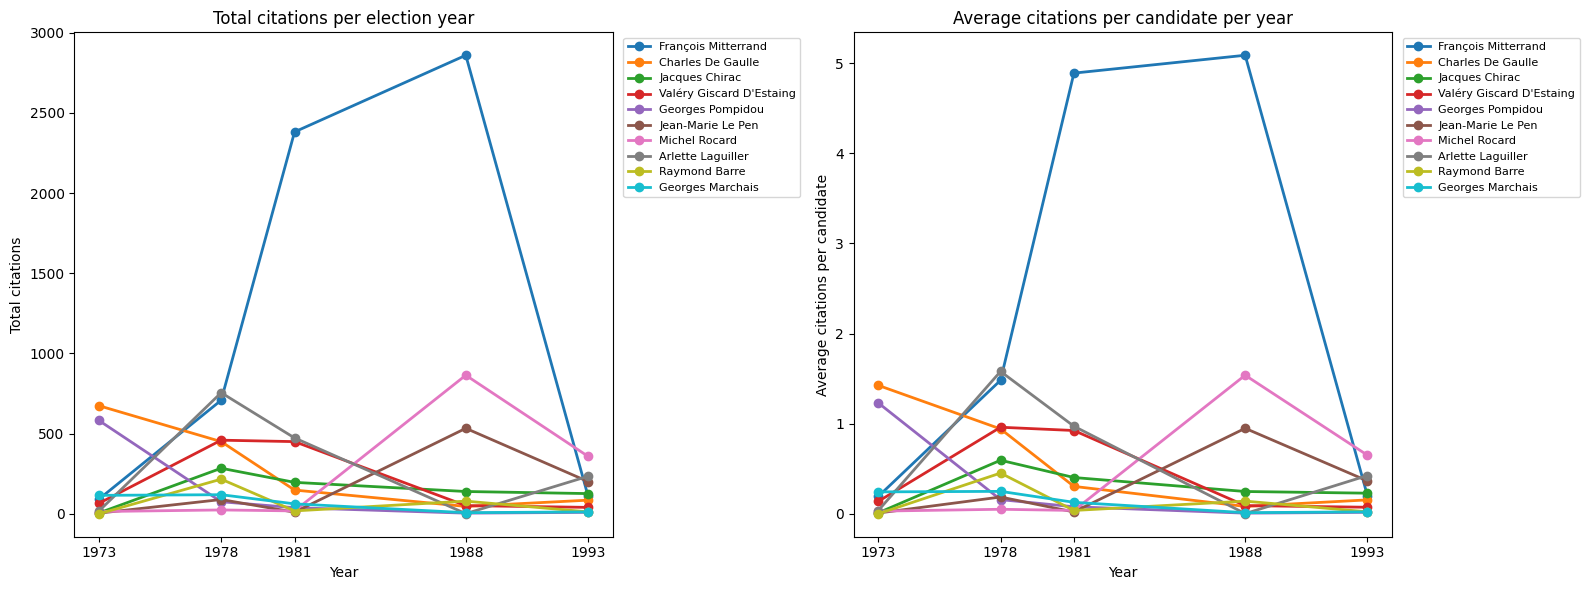

In [8]:
TOP_FIGURES = [
    "François Mitterrand", "Charles De Gaulle", "Jacques Chirac",
    "Valéry Giscard D'Estaing", "Georges Pompidou", "Jean-Marie Le Pen",
    "Michel Rocard", "Arlette Laguiller", "Raymond Barre", "Georges Marchais"
]

records = []
for _, row in df.iterrows():
    counts = Counter(row["persons_norm"])
    for figure in TOP_FIGURES:
        records.append({
            "year": row["year"],
            "figure": figure,
            "citations": counts.get(figure, 0)
        })

fig_df = pd.DataFrame(records)
fig_year = fig_df.groupby(["year", "figure"])["citations"].sum().reset_index()
n_candidates = df.groupby("year")["candidate_id"].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for figure in TOP_FIGURES:
    data = fig_year[fig_year["figure"] == figure]
    axes[0].plot(data["year"], data["citations"], marker="o", label=figure, linewidth=2)

axes[0].set_title("Total citations per election year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total citations")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].set_xticks([1973, 1978, 1981, 1988, 1993])

for figure in TOP_FIGURES:
    data = fig_year[fig_year["figure"] == figure].copy()
    data["citations_norm"] = data.apply(
        lambda r: r["citations"] / n_candidates[r["year"]], axis=1
    )
    axes[1].plot(data["year"], data["citations_norm"], marker="o", label=figure, linewidth=2)

axes[1].set_title("Average citations per candidate per year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average citations per candidate")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].set_xticks([1973, 1978, 1981, 1988, 1993])

plt.tight_layout()
plt.show()

Mitterrand's citations peak sharply in 1981 and 1988, coinciding with his presidential 
victories, then drop in 1993 as his presidency wound down. De Gaulle, who died in 1970, 
still generates substantial citations in 1973 and 1978 — a testament to his lasting 
symbolic weight in French politics. Le Pen appears progressively from 1988 onward, 
marking the rise of the Front National. The normalised plot confirms these trends are 
not simply an artefact of the growing number of candidates over the period.

### 7.2 Who cites whom?

Citation counts tell us when figures are mentioned, but not by whom. We now cross 
citation frequency with party affiliation to ask whether candidates invoke figures 
from their own camp or from the opposition.

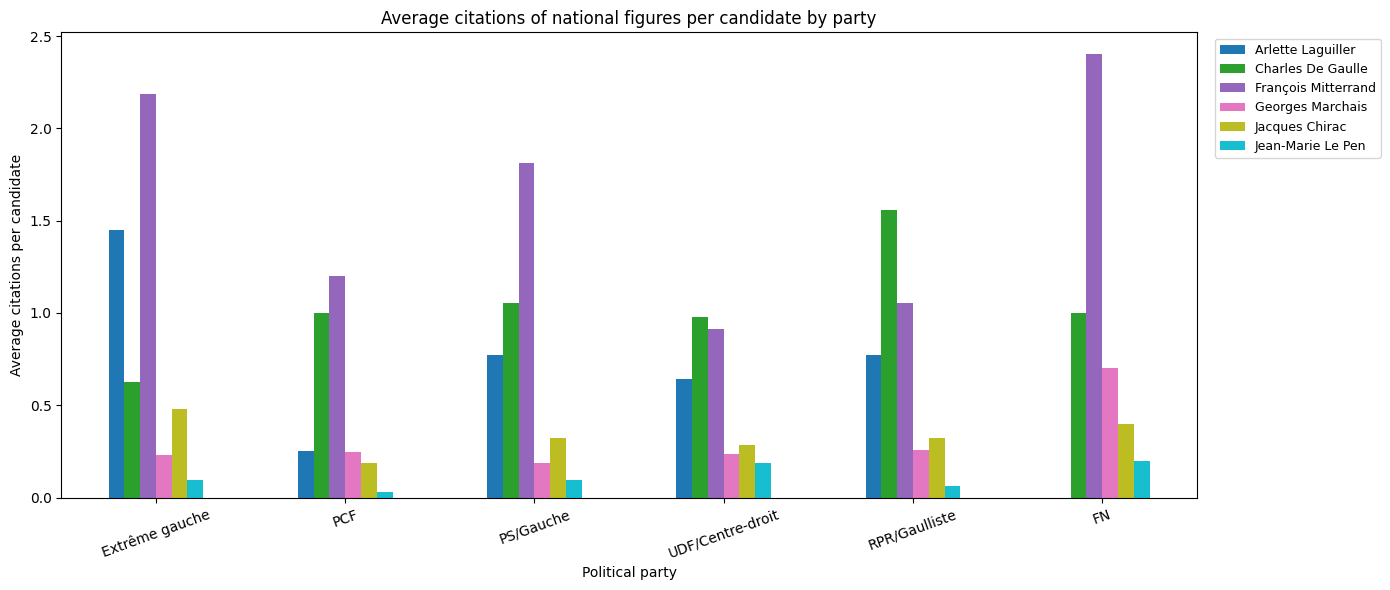

In [9]:
MAIN_PARTIES = ["PCF", "Extrême gauche", "PS/Gauche", "UDF/Centre-droit", "RPR/Gaulliste", "FN"]
MAIN_FIGURES = ["François Mitterrand", "Charles De Gaulle", "Georges Marchais",
                "Jacques Chirac", "Jean-Marie Le Pen", "Arlette Laguiller"]
party_order = ["Extrême gauche", "PCF", "PS/Gauche", "UDF/Centre-droit", "RPR/Gaulliste", "FN"]

df_pers_party = df[["candidate_id", "year", "persons_norm", "text_clean"]].merge(
    df_party[["candidate_id", "party"]],
    on="candidate_id", how="left"
)
df_pers_party = df_pers_party[df_pers_party["party"].isin(MAIN_PARTIES)]

party_citations = []
for _, row in df_pers_party.iterrows():
    counts = Counter(row["persons_norm"])
    for figure in MAIN_FIGURES:
        party_citations.append({
            "party": row["party"],
            "figure": figure,
            "citations": counts.get(figure, 0)
        })

pc_df = pd.DataFrame(party_citations)
pc_pivot = pc_df.groupby(["party", "figure"])["citations"].sum().unstack(fill_value=0)
n_per_party = df_pers_party.groupby("party")["candidate_id"].count()
pc_pivot_norm = pc_pivot.div(n_per_party, axis=0).reindex(party_order)

fig, ax = plt.subplots(figsize=(14, 6))
pc_pivot_norm.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Average citations of national figures per candidate by party")
ax.set_xlabel("Political party")
ax.set_ylabel("Average citations per candidate")
ax.tick_params(axis="x", rotation=20)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Mitterrand is cited across the entire political spectrum, including by RPR and FN 
candidates — almost certainly as a target of criticism rather than endorsement. De Gaulle 
remains a reference for all parties including the PS, reflecting his status as a founding 
figure of the Fifth Republic that transcends partisan lines. The PCF cites Marchais 
surprisingly rarely relative to Mitterrand, suggesting that even communist candidates 
felt compelled to engage with the dominant figure of the left. The FN's high Mitterrand 
citation rate (2.4 per candidate) is the most telling — it almost certainly reflects 
systematic opposition rhetoric.

Citation counts alone cannot tell us whether a mention reflects alignment or distancing. 
We now turn to a context window analysis to investigate this directly.

### 7.3 Alignment vs. distancing

For each citation of a national figure, we extract the 10 words before and after and 
search for positive markers (support, endorsement) and negative markers (opposition, 
criticism). The alignment score is computed as (positive - negative) / (positive + 
negative), ranging from -1 (pure distancing) to +1 (pure endorsement). This is a simple 
lexicon-based heuristic — it does not require a trained sentiment model, but it comes 
with known limitations that we discuss below.

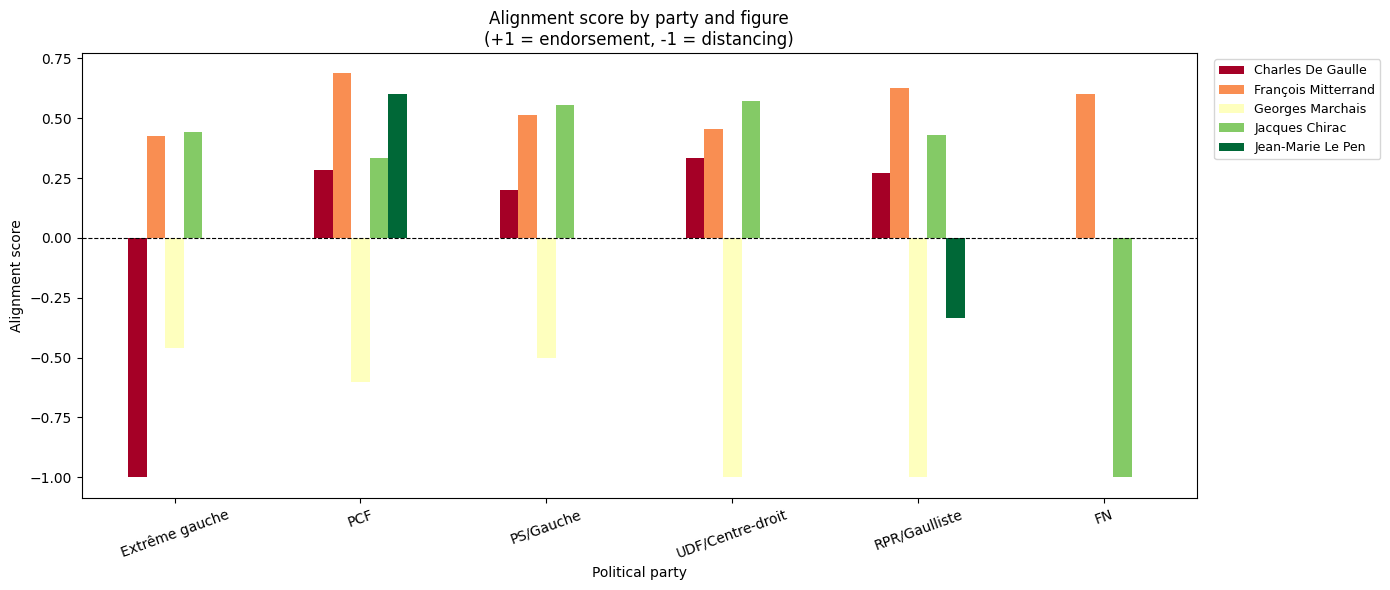


Alignment scores:
figure            Charles De Gaulle  François Mitterrand  Georges Marchais  \
party                                                                        
Extrême gauche                -1.00                 0.43             -0.46   
PCF                            0.29                 0.69             -0.60   
PS/Gauche                      0.20                 0.51             -0.50   
UDF/Centre-droit               0.33                 0.45             -1.00   
RPR/Gaulliste                  0.27                 0.63             -1.00   
FN                             0.00                 0.60              0.00   

figure            Jacques Chirac  Jean-Marie Le Pen  
party                                                
Extrême gauche              0.44               0.00  
PCF                         0.33               0.60  
PS/Gauche                   0.56               0.00  
UDF/Centre-droit            0.57               0.00  
RPR/Gaulliste               0.43

In [10]:
POSITIVE_MARKERS = {
    "soutien", "soutiens", "soutient", "appui", "approuve", "approuvons",
    "fidèle", "fidèles", "avec", "partisan", "partisans", "défend", "défendre",
    "suit", "suivons", "accord", "favorable", "ensemble", "solidaire",
    "rallie", "rallions", "confiance", "espoir", "succès", "victoire"
}

NEGATIVE_MARKERS = {
    "contre", "oppose", "opposons", "opposition", "contrairement", "contraire",
    "refuse", "refusons", "refus", "critique", "critiquons", "critiquer",
    "échec", "erreur", "danger", "menace", "trahison", "abandon", "rupture",
    "non", "jamais", "sans", "ni", "mais", "cependant", "pourtant",
    "dénonçons", "dénonce", "combattons", "combat",
    "racisme", "raciste", "fascisme", "fasciste", "xénophobie",
    "honte", "inacceptable", "condamne", "condamnons",
    "coupables", "responsables", "immigration", "insécurité"
}

def analyze_context(text, name, window=10):
    positive = 0
    negative = 0
    text_norm = text.lower().replace("-", " ")
    name_norm = name.lower().replace("-", " ")
    words = text_norm.split()
    name_words = name_norm.split()
    n = len(name_words)
    for i in range(len(words) - n + 1):
        if words[i:i+n] == name_words:
            start = max(0, i - window)
            end = min(len(words), i + n + window)
            context = set(words[start:end])
            positive += len(context & POSITIVE_MARKERS)
            negative += len(context & NEGATIVE_MARKERS)
    return positive, negative

FIGURES_TO_ANALYSE = [
    "François Mitterrand", "Charles De Gaulle",
    "Jean-Marie Le Pen", "Jacques Chirac", "Georges Marchais"
]

results = []
for _, row in df_pers_party.iterrows():
    for figure in FIGURES_TO_ANALYSE:
        pos, neg = analyze_context(row["text_clean"], figure)
        if pos + neg > 0:
            results.append({
                "party": row["party"],
                "figure": figure,
                "positive": pos,
                "negative": neg,
            })

results_df = pd.DataFrame(results)
alignment = results_df.groupby(["party", "figure"])[["positive", "negative"]].sum()
alignment["score"] = (alignment["positive"] - alignment["negative"]) / \
                     (alignment["positive"] + alignment["negative"])
alignment = alignment["score"].unstack(fill_value=0).reindex(party_order)

fig, ax = plt.subplots(figsize=(14, 6))
alignment.plot(kind="bar", ax=ax, colormap="RdYlGn")
ax.set_title("Alignment score by party and figure\n(+1 = endorsement, -1 = distancing)")
ax.set_xlabel("Political party")
ax.set_ylabel("Alignment score")
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.tick_params(axis="x", rotation=20)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("\nAlignment scores:")
print(alignment.round(2))

Several results are historically coherent. Mitterrand is cited positively by PCF (0.69) 
and PS/Gauche (0.51), reflecting the Union de la gauche alliance. The RPR also scores 
positively on Mitterrand (0.63), consistent with Chirac's known strategic ambiguity — 
he famously refused to give a clear voting instruction against Mitterrand in 1981. 
De Gaulle is cited negatively by the Extrême gauche (-1.00) and positively by the RPR 
and UDF. Marchais is cited negatively across the board, including by the PCF itself 
(-0.60), reflecting the declining credibility of the communist leadership after his poor 
1981 presidential result. The RPR cites Le Pen negatively (-0.33), consistent with the 
mainstream right's efforts to distance itself from the Front National.

Some results are less reliable. The PCF scores positively on Le Pen (0.60), which is 
historically implausible. Inspection of the context windows around Le Pen mentions 
shows that most citations are administrative — "candidats présentés par le Front 
National", "liste Le Pen" — rather than rhetorical. The lexicon cannot distinguish 
between a candidate who denounces Le Pen and one who simply lists him as a competitor 
on the ballot. A sentiment model trained on political French text would be needed to 
resolve this ambiguity.

## 8. Analysis — Part 2: Spatial discourse

The second question is whether candidates frame their discourse locally or project toward 
national and international stakes. We use the LOC entities extracted in section 5, but 
rather than trying to classify every detected location — which proved unreliable on this 
noisy OCR corpus — we focus on a curated list of unambiguous geographic references: the 
five departments covered by the corpus, their main cities, and a set of foreign countries 
and supranational entities.

Total geographic mentions across all manifestos:
  Local:         1528
  National:      11863
  International: 4563


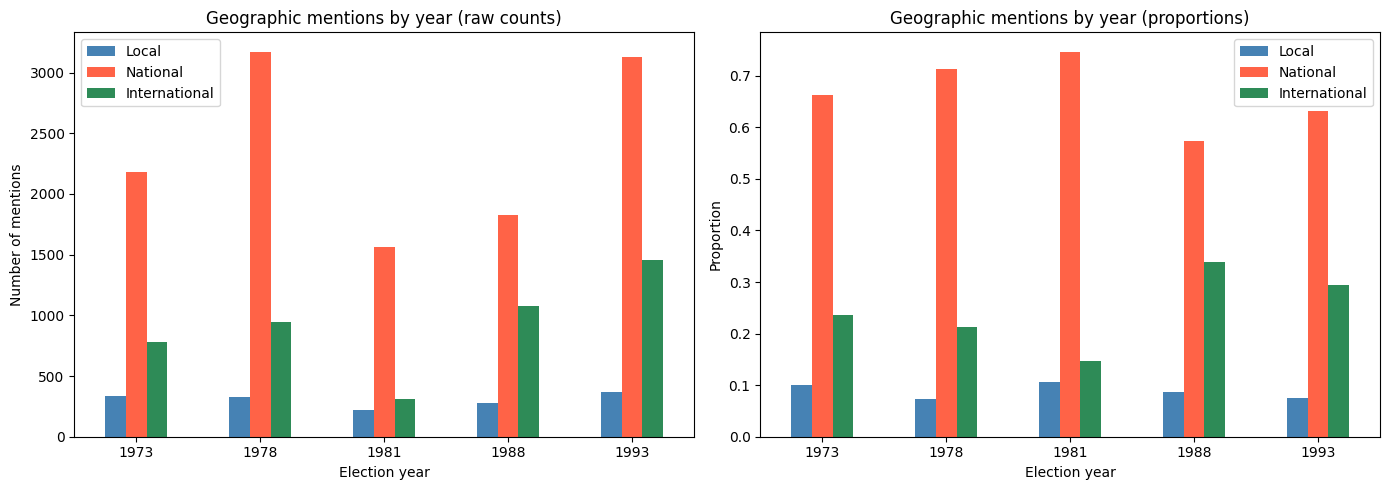

In [11]:
LOCAL_REFS = {
    "Bas-Rhin", "Haut-Rhin", "Rhône", "Pyrénées-Orientales", "Hautes-Pyrénées",
    "Strasbourg", "Mulhouse", "Colmar", "Lyon", "Perpignan", "Tarbes"
}

NATIONAL_REFS = {
    "France", "Paris", "République", "Nation", "Gouvernement"
}

INTERNATIONAL_REFS = {
    "Europe", "États-Unis", "Allemagne", "Russie", "Urss",
    "Algérie", "Afrique", "Chine", "Maroc", "Israël"
}

def classify_locations(locations):
    scores = {"local": 0, "national": 0, "international": 0}
    for loc in locations:
        loc_norm = normalize_case(loc)
        if loc_norm in LOCAL_REFS:
            scores["local"] += 1
        elif loc_norm in NATIONAL_REFS:
            scores["national"] += 1
        elif loc_norm in INTERNATIONAL_REFS:
            scores["international"] += 1
    return scores

df["geo_scores"] = df["locations"].apply(classify_locations)
df["geo_local"] = df["geo_scores"].apply(lambda s: s["local"])
df["geo_national"] = df["geo_scores"].apply(lambda s: s["national"])
df["geo_international"] = df["geo_scores"].apply(lambda s: s["international"])

total = df[["geo_local", "geo_national", "geo_international"]].sum()
print("Total geographic mentions across all manifestos:")
print(f"  Local:         {total['geo_local']}")
print(f"  National:      {total['geo_national']}")
print(f"  International: {total['geo_international']}")

geo_by_year = df.groupby("year")[["geo_local", "geo_national", "geo_international"]].sum()
geo_by_year_norm = geo_by_year.div(geo_by_year.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
geo_by_year.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato", "seagreen"])
axes[0].set_title("Geographic mentions by year (raw counts)")
axes[0].set_xlabel("Election year")
axes[0].set_ylabel("Number of mentions")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Local", "National", "International"])

geo_by_year_norm.plot(kind="bar", ax=axes[1], color=["steelblue", "tomato", "seagreen"])
axes[1].set_title("Geographic mentions by year (proportions)")
axes[1].set_xlabel("Election year")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Local", "National", "International"])

plt.tight_layout()
plt.show()

National references dominate throughout the period. Even in legislative elections — 
which are inherently local contests — candidates systematically frame their discourse 
around France, the Republic, and the government rather than their own constituency. 
The most notable trend is the rise of international mentions from 1988 onward, most 
likely driven by the Maastricht debate of 1992, which brought European integration to 
the centre of political discourse.

Most cited international locations:
  Europe: 3295
  Algérie: 425
  Allemagne: 320
  Russie: 178
  Afrique: 175
  Maroc: 56
  Chine: 44
  États-Unis: 38
  Israël: 32


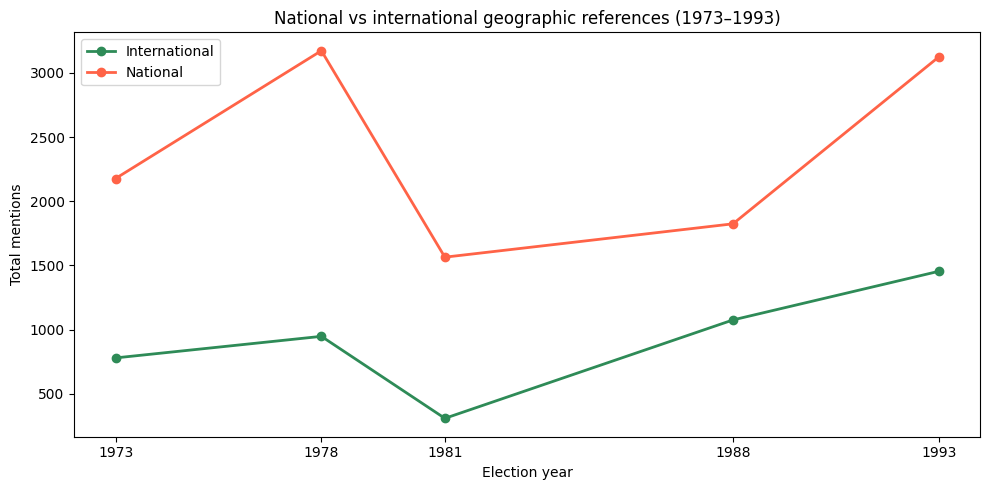

In [12]:
intl_mentions = []
for locs in df["locations"]:
    for loc in locs:
        if normalize_case(loc) in INTERNATIONAL_REFS:
            intl_mentions.append(normalize_case(loc))

intl_counts = Counter(intl_mentions)
print("Most cited international locations:")
for loc, count in intl_counts.most_common():
    print(f"  {loc}: {count}")

intl_by_year = df.groupby("year")["geo_international"].sum()
nat_by_year = df.groupby("year")["geo_national"].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(intl_by_year.index, intl_by_year.values, marker="o",
        label="International", color="seagreen", linewidth=2)
ax.plot(nat_by_year.index, nat_by_year.values, marker="o",
        label="National", color="tomato", linewidth=2)
ax.set_title("National vs international geographic references (1973–1993)")
ax.set_xlabel("Election year")
ax.set_ylabel("Total mentions")
ax.set_xticks([1973, 1978, 1981, 1988, 1993])
ax.legend()
plt.tight_layout()
plt.show()

Europe dominates international references with 3,295 mentions, far ahead of Algeria 
(425) and Germany (320). The Algerian figure likely reflects the lasting political weight 
of decolonisation, particularly in Alsace and the Pyrénées where repatriate communities 
were significant. The sharp rise in international mentions from 1988 onward confirms the 
growing salience of European integration in French electoral discourse.

### 8.1 Geographic scope by political party

If spatial framing varies systematically across parties, this would suggest it reflects 
ideological positioning rather than individual style. We expect left-wing parties to 
reference international solidarity more, while Gaullist candidates might emphasise 
national sovereignty.

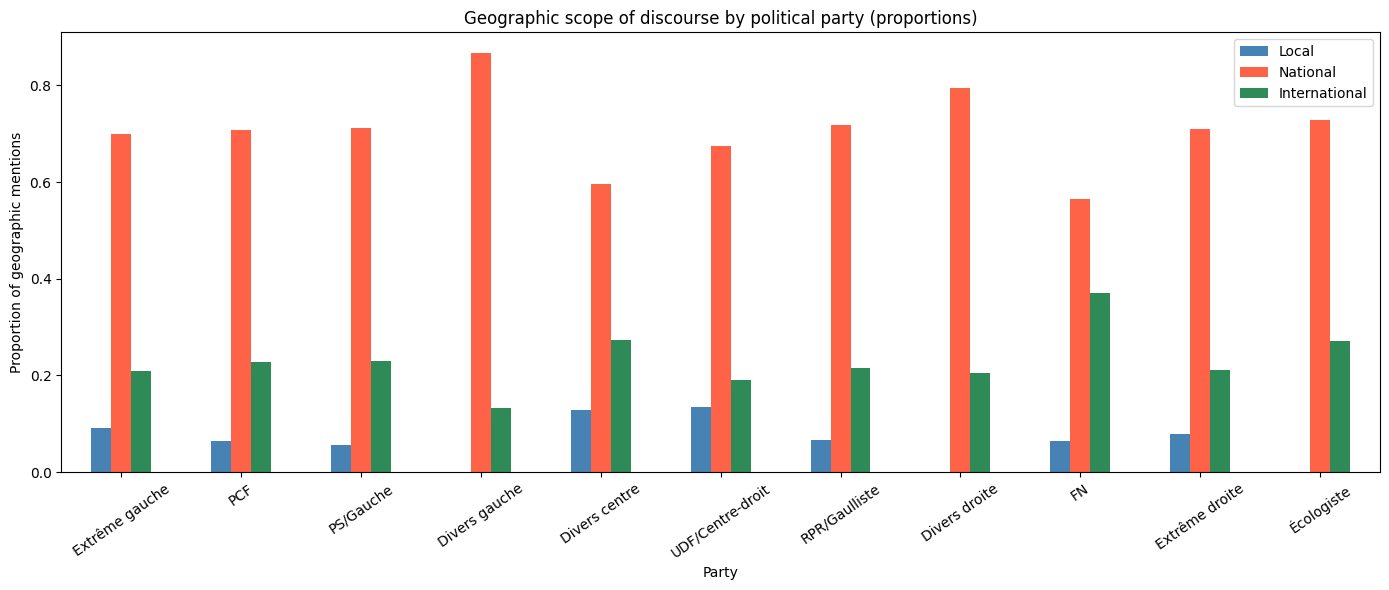

In [13]:
df_party["geo_local"] = df["geo_local"]
df_party["geo_national"] = df["geo_national"]
df_party["geo_international"] = df["geo_international"]

df_plot = df_party[df_party["party"] != "Non mentionné"].copy()

party_geo = df_plot.groupby("party")[["geo_local", "geo_national", "geo_international"]].sum()
party_geo_norm = party_geo.div(party_geo.sum(axis=1), axis=0)

full_party_order = [
    "Extrême gauche", "PCF", "PS/Gauche", "Divers gauche",
    "Divers centre", "UDF/Centre-droit", "RPR/Gaulliste",
    "Divers droite", "FN", "Extrême droite", "Écologiste"
]
party_geo_norm = party_geo_norm.reindex(full_party_order).dropna()

fig, ax = plt.subplots(figsize=(14, 6))
party_geo_norm.plot(kind="bar", ax=ax, color=["steelblue", "tomato", "seagreen"])
ax.set_title("Geographic scope of discourse by political party (proportions)")
ax.set_xlabel("Party")
ax.set_ylabel("Proportion of geographic mentions")
ax.tick_params(axis="x", rotation=35)
ax.legend(["Local", "National", "International"])
plt.tight_layout()
plt.show()

The Front National stands out with the highest share of international references (37%), 
likely reflecting anti-European and immigration rhetoric rather than genuine 
internationalist solidarity. The PCF and PS/Gauche show similar international proportions 
(around 22%), consistent with their tradition of workers' solidarity across borders. 
Gaulliste candidates have lower international references, reflecting the Gaullist emphasis 
on national sovereignty. The Divers centre group shows the most overwhelmingly national 
framing, which may reflect the technocratic, state-centred rhetoric typical of centrist 
candidates in this period.

### 8.2 Geographic scope by department

The corpus covers five departments: Bas-Rhin, Haut-Rhin, Rhône, Pyrénées-Orientales 
and Hautes-Pyrénées. Despite their small number, they represent contrasting geographic 
and political contexts — Alsace borders Germany and has a strong regional identity, 
while the Pyrénées departments are more peripheral and border Spain.

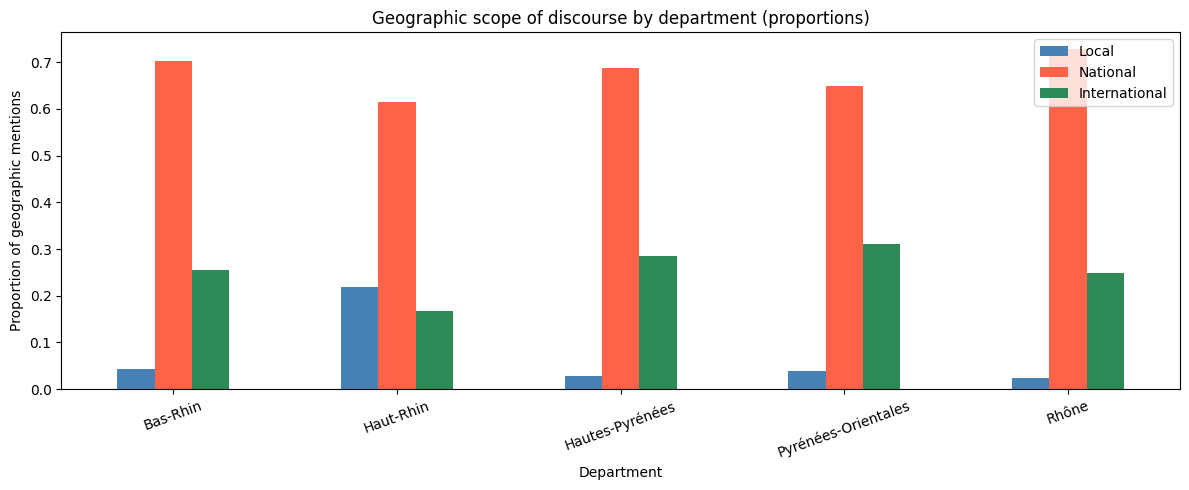


Raw numbers:
                     geo_local  geo_national  geo_international
dept_name                                                      
Bas-Rhin                    19           311                113
Haut-Rhin                  261           736                200
Hautes-Pyrénées             14           333                138
Pyrénées-Orientales         25           407                195
Rhône                       13           390                133


In [14]:
url = "https://geo.api.gouv.fr/departements?fields=nom,code"
with urllib.request.urlopen(url) as response:
    depts = json.loads(response.read())

dept_code_to_name = {d["code"]: normalize_case(d["nom"]) for d in depts}
df_party["dept_code"] = df_party["dept"].str.replace("EL", "").str.lstrip("0")
df_party["dept_name"] = df_party["dept_code"].map(dept_code_to_name)

dept_geo = df_party.groupby("dept_name")[["geo_local", "geo_national", "geo_international"]].sum()
dept_geo_norm = dept_geo.div(dept_geo.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
dept_geo_norm.plot(kind="bar", ax=ax, color=["steelblue", "tomato", "seagreen"])
ax.set_title("Geographic scope of discourse by department (proportions)")
ax.set_xlabel("Department")
ax.set_ylabel("Proportion of geographic mentions")
ax.tick_params(axis="x", rotation=20)
ax.legend(["Local", "National", "International"])
plt.tight_layout()
plt.show()

print("\nRaw numbers:")
print(dept_geo)

The Haut-Rhin stands out with a markedly higher share of local references (22%), 
reflecting the strong regional identity of Alsace — candidates there invoke their 
cities and department by name more frequently than elsewhere. The two Pyrénées 
departments show the highest international proportions, likely due to their proximity 
to Spain and the salience of cross-border issues. The Rhône and Bas-Rhin show a more 
typically national framing.

These results should be interpreted with caution. Five departments is a very small 
sample, and the corpus was not designed to be geographically representative of France 
as a whole.

### 8.3 Link between personality citations and geographic scope

We now connect the two analyses. If candidates who invoke national figures also tend 
to frame their discourse in national rather than local terms, sponsorship and spatial 
orientation would be two expressions of the same rhetorical strategy. We test this by 
computing the correlation between citation frequency and geographic scope for the three 
most cited figures.

Correlation between figure citations and national geographic share:
  François Mitterrand: 0.028
  Charles De Gaulle: 0.023
  Jean-Marie Le Pen: -0.082

Correlation between figure citations and international share:
  François Mitterrand: -0.032
  Charles De Gaulle: -0.047
  Jean-Marie Le Pen: 0.094


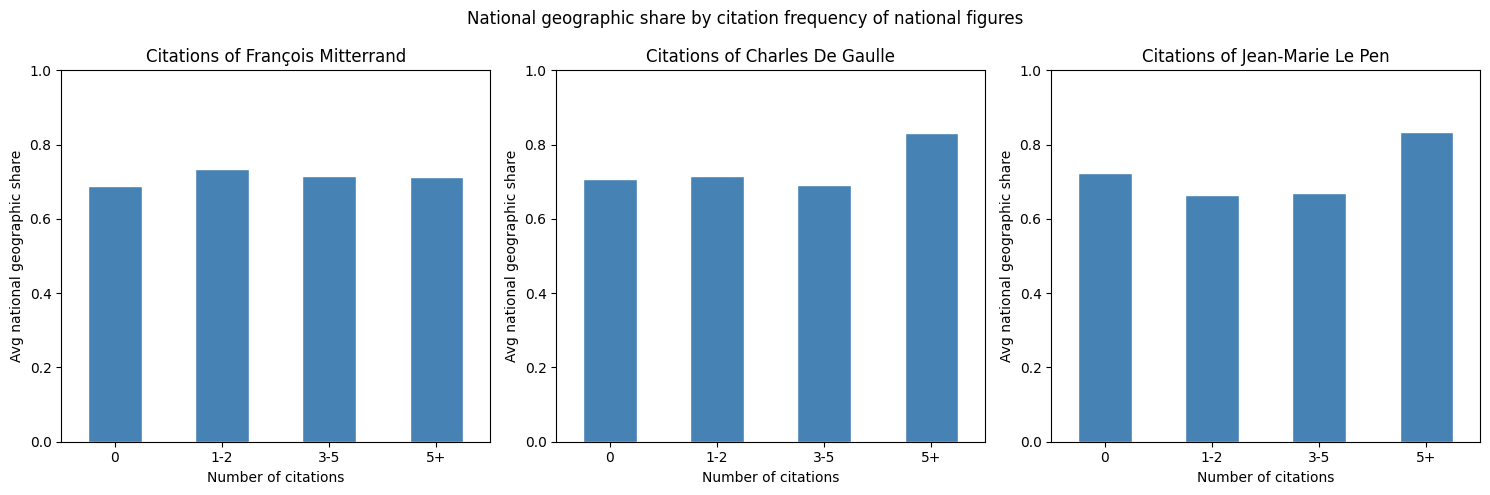

In [15]:
TOP_FIGURES_LINK = ["François Mitterrand", "Charles De Gaulle", "Jean-Marie Le Pen"]

link_records = []
for _, row in df.iterrows():
    counts = Counter(row["persons_norm"])
    total_geo = row["geo_local"] + row["geo_national"] + row["geo_international"]
    record = {
        "candidate_id": row["candidate_id"],
        "national_share": row["geo_national"] / total_geo if total_geo > 0 else None,
        "intl_share": row["geo_international"] / total_geo if total_geo > 0 else None,
    }
    for figure in TOP_FIGURES_LINK:
        record[figure] = counts.get(figure, 0)
    link_records.append(record)

link_df = pd.DataFrame(link_records).dropna(subset=["national_share"])

print("Correlation between figure citations and national geographic share:")
for figure in TOP_FIGURES_LINK:
    corr = link_df[figure].corr(link_df["national_share"])
    print(f"  {figure}: {corr:.3f}")

print("\nCorrelation between figure citations and international share:")
for figure in TOP_FIGURES_LINK:
    corr = link_df[figure].corr(link_df["intl_share"])
    print(f"  {figure}: {corr:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, figure in enumerate(TOP_FIGURES_LINK):
    link_df["citations_bin"] = pd.cut(link_df[figure],
                                       bins=[-1, 0, 2, 5, 100],
                                       labels=["0", "1-2", "3-5", "5+"])
    means = link_df.groupby("citations_bin", observed=True)["national_share"].mean()
    means.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="white")
    axes[i].set_title(f"Citations of {figure}")
    axes[i].set_xlabel("Number of citations")
    axes[i].set_ylabel("Avg national geographic share")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].set_ylim(0, 1)

plt.suptitle("National geographic share by citation frequency of national figures")
plt.tight_layout()
plt.show()

The correlations between citation frequency and geographic scope are negligible for 
Mitterrand (0.028) and De Gaulle (0.023), and very weak for Le Pen (0.094). The bar 
charts confirm this visually — the national geographic share stays stable at around 70% 
regardless of how often a candidate cites these figures. Sponsorship and spatial 
discourse are two independent rhetorical dimensions: a candidate can heavily invoke 
Mitterrand while still anchoring their discourse locally. The two analyses capture 
distinct aspects of electoral rhetoric rather than two facets of the same strategy.

## 9. Conclusion

This notebook applied Named Entity Recognition to the Archelec corpus to investigate 
two dimensions of electoral discourse in French legislative manifestos between 1973 
and 1993.

On the sponsorship dimension, Mitterrand dominates citation counts across the entire 
political spectrum, peaking in 1981 and 1988 in line with his presidential victories. 
De Gaulle remains a reference even decades after his death, invoked across party lines 
as a founding symbol of the Fifth Republic. The context window analysis suggests that 
cross-party citations of opposing figures reflect distancing rather than endorsement in 
most cases, though the lexicon-based approach has known limits on administrative 
citation contexts.

On the spatial dimension, national references dominate throughout — candidates frame 
their manifestos around France and the Republic rather than their local constituency, 
even in elections that are inherently local contests. International references grow 
markedly from 1988 onward, driven by the Maastricht debate. Geographic scope varies 
by department (Haut-Rhin is notably more local) and by party (the FN is notably more 
international), but the two dimensions of analysis — sponsorship and spatial framing — 
turn out to be largely independent of one another.